# MC_Maze — load & explore

**Capstone, step 1: get the data into shape and understand it.**

We load the MC_Maze dataset (macaque M1 / PMd during delayed reaches; Churchland &
Shenoy labs) via [`nlb_tools`](https://github.com/neurallatents/nlb_tools) and build
a small set of **base loader functions** that turn the raw NWB file into:

- **binned spikes** (137 held-in neurons),
- **reach conditions** (per-trial reach target / direction),
- **hand velocity** (and other kinematics), trial-aligned to movement onset.

> Data source: DANDI dandiset **000128**, file
> `sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb` (~690 MB, gitignored).

### Prediction (to write together, *before* any tuning plot)
> _TODO — before plotting a single tuning curve, write one prediction here: what
> should a motor-cortex neuron's firing-rate-vs-reach-direction curve look like, and
> why?_

### Roadmap
1. **(this notebook)** load → binned spikes + reach conditions + hand velocity.
2. Understand the data (guided): sanity-check kinematics, the reach-direction
   definition, per-neuron activity.
3. Per-neuron directional **tuning curves**.
4. PCA of the population → reach-direction **decoder**.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nlb_tools.nwb_interface import NWBDataset

# --- config --------------------------------------------------------------
BIN_WIDTH_MS = 20      # spike-count bin size (native NWB resolution is 1 ms)


def _find_train_nwb():
    """Locate the MC_Maze train file whether run from ./notebooks or repo root."""
    rel = Path("data") / "000128" / "sub-Jenkins" / \
        "sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb"
    for base in (Path.cwd(), Path.cwd().parent):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(
        f"Could not find {rel} — run the download step in the README.")


TRAIN_NWB = _find_train_nwb()
print("train file:", TRAIN_NWB)
print(f"size: {TRAIN_NWB.stat().st_size / 1e6:.0f} MB")

## 1. Load the raw dataset (1 ms bins)

`NWBDataset` reads the NWB file into two objects:

- **`.data`** — a continuous, time-indexed DataFrame (1 ms) with a column
  MultiIndex `(signal, channel)`: `spikes`, `heldout_spikes`, `hand_pos`,
  `hand_vel`, `cursor_pos`, `eye_pos`.
- **`.trial_info`** — one row per trial (targets, alignment events, success).

We only use the 137 held-in `spikes`; `heldout_spikes` exist for the NLB
co-smoothing benchmark and are ignored here.

In [10]:
def load_mc_maze(nwb_path):
    """Load the MC_Maze train file into an nlb_tools ``NWBDataset``.

    ``.data`` is continuous at 1 ms (spikes + hand/cursor/eye kinematics);
    ``.trial_info`` has one row per trial (targets, alignment events, success).
    """
    return NWBDataset(str(nwb_path))


dataset = load_mc_maze(TRAIN_NWB)

print("native bin width (ms):", dataset.bin_width)
print("continuous samples   :", dataset.data.shape[0], "(1 ms each)")
print("held-in neurons      :", dataset.data["spikes"].shape[1])
print("trials               :", len(dataset.trial_info))
print("signals              :", list(dataset.data.columns.get_level_values(0).unique()))

/Users/prateekkarkare/Desktop/Personal/Projects/motor-cortex-population-dynamics/.venv/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.4.0, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


native bin width (ms): 1
continuous samples   : 6952301 (1 ms each)
held-in neurons      : 137
trials               : 2295
signals              : ['cursor_pos', 'eye_pos', 'hand_pos', 'hand_vel', 'heldout_spikes', 'spikes']


## 2. Bin the spikes

Resample from 1 ms to `BIN_WIDTH_MS`. Spikes are **summed** per bin (counts);
continuous signals (hand velocity, etc.) are **averaged**. This mutates the
dataset in place — re-run the load cell to get back to 1 ms.

In [11]:
def bin_spikes(ds, bin_width_ms=BIN_WIDTH_MS):
    """Resample ``ds`` to ``bin_width_ms`` bins (in place) and return it.

    nlb_tools 0.0.4 targets pandas <= 1.3.4. Two things break under pandas >= 1.5,
    both fixed here:
      1. ``resample`` ends with ``data.index.freq = "<n>ms"``, which newer pandas
         validates strictly and rejects (the data is already rebinned by then).
      2. Without a proper index ``freq``, ``make_trial_data``'s ``slice_indexer``
         (slicing by non-bin-edge event times) fails.
    So we catch the freq error and rebuild a clean, regular ``TimedeltaIndex``.
    """
    if ds.bin_width == bin_width_ms:
        return ds
    n_before = ds.data.shape[0]
    try:
        ds.resample(bin_width_ms)
    except ValueError:
        assert ds.data.shape[0] < n_before, "resample did not actually rebin"
        ds.bin_width = bin_width_ms
    ds.data.index = pd.timedelta_range(
        start=ds.data.index[0], periods=len(ds.data),
        freq=f"{bin_width_ms}ms", name="clock_time",
    )
    assert ds.bin_width == bin_width_ms
    return ds


bin_spikes(dataset, BIN_WIDTH_MS)

# sanity: median spacing of the binned index should equal the bin width
_step_ms = np.median(np.diff(dataset.data.index.total_seconds())) * 1000
print("bin width (ms):", dataset.bin_width, f"(median index step {_step_ms:.1f} ms)")
print("binned samples:", dataset.data.shape[0])
print("spikes block  :", dataset.data["spikes"].shape)

bin width (ms): 20 (median index step 20.0 ms)
binned samples: 347616
spikes block  : (347616, 137)


## 3. Reach conditions per trial

Each trial shows up to 3 targets (`target_pos`); `active_target` indexes the one
actually reached to. The reach **direction** is the angle of that target from the
center hold.

> In the maze task the *path* can curve around barriers, so "target direction" and
> "instantaneous hand direction" are not identical — which one counts as *reach
> direction* is a modelling choice we'll revisit before building tuning curves.
> This function surfaces the target-based angle plus the raw fields.

In [13]:
def reach_conditions(ds):
    """One row per trial describing *where the reach went*.

    The reached target is ``target_pos[active_target]``; ``reach_angle_deg`` is
    the direction of that target from center (target-based reach direction).
    """
    ti = ds.trial_info
    target_pos = ti["target_pos"].to_numpy()
    active = ti["active_target"].to_numpy()
    xy = np.array([np.asarray(target_pos[i], dtype=float)[active[i]]
                   for i in range(len(ti))])
    x, y = xy[:, 0], xy[:, 1]
    return pd.DataFrame({
        "trial_id": ti["trial_id"].to_numpy(),
        "target_x": x,
        "target_y": y,
        "reach_angle_deg": np.degrees(np.arctan2(y, x)),
        "reach_dist": np.hypot(x, y),
        "trial_type": ti["trial_type"].to_numpy(),
        "maze_id": ti["maze_id"].to_numpy(),
        "num_targets": ti["num_targets"].to_numpy(),
        "success": ti["success"].to_numpy(),
        "move_onset_time": ti["move_onset_time"].to_numpy(),
    })


conditions = reach_conditions(dataset)
print(conditions.shape)
conditions.head()

(2295, 10)


,trial_id,target_x,target_y,reach_angle_deg,reach_dist,trial_type,maze_id,num_targets,success,move_onset_time
0,0,118.0,72.0,31.390268,138.231690,25,84,3,True,0 days 00:00:01.905000
1,1,-116.0,-5.0,-177.531882,116.107709,3,3,1,True,0 days 00:00:05.280000
2,2,-82.0,-86.0,-133.636072,118.827606,22,66,1,True,0 days 00:00:08.346000
3,3,2.0,82.0,88.602819,82.024387,29,100,3,True,0 days 00:00:11.752000
4,4,27.0,82.0,71.774925,86.330759,21,65,1,True,0 days 00:00:14.507000


## 4. Trial-aligned spikes + hand velocity

`make_trial_data` cuts the continuous data into per-trial segments aligned to a
task event (here **movement onset**) within a time window. Bin edges are relative
to the alignment event, so trials become directly comparable — the form we'll use
to compute per-neuron firing rates by reach direction.

In [12]:
def make_trial_spikes(ds, align_field="move_onset_time", window_ms=(-200, 600)):
    """Trial-aligned binned data around a task event.

    Returns the nlb_tools trial DataFrame: every trial's binned spikes and
    kinematics (incl. ``hand_vel``), clipped to ``window_ms`` around
    ``align_field`` (e.g. movement onset), plus meta columns like ``trial_id``
    and ``align_time``.
    """
    return ds.make_trial_data(align_field=align_field, align_range=window_ms)


trials = make_trial_spikes(dataset)
bins_per_trial = int((600 - (-200)) / dataset.bin_width)
print("trial-aligned rows :", trials.shape[0])
print("signals (level 0)  :", list(trials.columns.get_level_values(0).unique()))
print("expected bins/trial:", bins_per_trial, f"(-200..600 ms @ {dataset.bin_width} ms)")
trials.head()

NaNs found in `self.data`. Dropping 2.05% of points to remove NaNs from `trial_data`.


trial-aligned rows : 89920
signals (level 0)  : ['align_time', 'clock_time', 'cursor_pos', 'eye_pos', 'hand_pos', 'hand_vel', 'heldout_spikes', 'margin', 'spikes', 'trial_id', 'trial_time']
expected bins/trial: 40 (-200..600 ms @ 20 ms)


align_time             clock_time cursor_pos            \
                                                           x         y   
0 -1 days +23:59:59.800000 0 days 00:00:01.720000  -1.499739 -7.629926   
1 -1 days +23:59:59.820000 0 days 00:00:01.740000  -1.499857 -7.597105   
2 -1 days +23:59:59.840000 0 days 00:00:01.760000  -1.497862 -7.612576   
3 -1 days +23:59:59.860000 0 days 00:00:01.780000  -1.500481 -7.648724   
4 -1 days +23:59:59.880000 0 days 00:00:01.800000  -1.495339 -7.611032   

      eye_pos             hand_pos             hand_vel            ... spikes  \
            x          y         x          y         x         y  ...   2861   
0  -18.223019  -0.655376 -1.522926 -42.630193  0.311218  0.161879  ...    0.0   
1  -19.047413  -1.079590 -1.509622 -42.630682  0.383868 -0.721782  ...    0.0   
2   -7.023040   0.458028 -1.518505 -42.645698 -0.848503  0.204770  ...    0.0   
3   90.972647  14.199807 -1.518529 -42.631233  0.849756 -0.485864  ...    0.0   
4  151.015360  14.063791 -1.509818 -42.708989 -0.280203 -6.327893  ...    0.0   

                                     trial_id             trial_time  
  2862 2871 2881 2911 2931 2951 2961                                  
0  2.0  0.0  0.0  0.0  0.0  0.0  1.0        0 0 days 00:00:01.720000  
1  0.0  0.0  0.0  0.0  0.0  0.0  2.0        0 0 days 00:00:01.740000  
2  0.0  0.0  0.0  0.0  1.0  0.0  0.0        0 0 days 00:00:01.760000  
3  0.0  0.0  0.0  0.0  1.0  1.0  0.0        0 0 days 00:00:01.780000  
4  0.0  0.0  1.0  0.0  0.0  0.0  0.0        0 0 days 00:00:01.800000  

[5 rows x 195 columns]

## Understanding the data first (guided)

Base loaders are in place (`load_mc_maze` → `bin_spikes` → `reach_conditions` +
`make_trial_spikes`). Before any tuning curve, we work through basic questions to
*understand* the data — starting with the visual sanity checks below.

Still to decide before tuning: how to define **reach direction** (target angle vs
hand-velocity angle) and the **firing-rate window**. _No tuning-curve code yet._

## 5. Visual sanity checks — one trial

Before any analysis, *look* at a single trial: (a) a spike **raster** of all held-in
neurons, and (b) a **workspace diagram** (targets, barriers, cursor / hand / eye
paths) plus the kinematics over time.

Rasters want spike-time resolution, so we keep a fresh **1 ms** copy (`ds_fine`) —
the `dataset` above was binned to 20 ms in place. First, a numeric peek at one
trial so the picture below is unambiguous (which coordinate frame is which, how
`barrier_pos` is encoded).

In [14]:
# Fresh 1 ms copy for visualisation (binning above was in place / destructive).
ds_fine = load_mc_maze(TRAIN_NWB)

EX_TRIAL = 2  # a single-target trial (num_targets == 1) is easiest to read first
row = ds_fine.trial_info[ds_fine.trial_info["trial_id"] == EX_TRIAL].iloc[0]

targets = np.asarray(row["target_pos"], dtype=float)
barriers = np.asarray(row["barrier_pos"], dtype=float)
print(f"trial {EX_TRIAL}: num_targets={row['num_targets']} active={row['active_target']} "
      f"num_barriers={row['num_barriers']}")
print("targets      :", targets.tolist())
print("active target:", targets[row["active_target"]].tolist())
print("barrier_pos rows (4 cols each):", barriers.tolist()[:3], "...")
print("events (s): target_on={:.3f} go_cue={:.3f} move_onset={:.3f} end={:.3f}".format(
    row["target_on_time"].total_seconds(), row["go_cue_time"].total_seconds(),
    row["move_onset_time"].total_seconds(), row["end_time"].total_seconds()))

# which position signal shares the target coordinate frame?
start, end = row["start_time"], row["end_time"]
for sig in ["cursor_pos", "hand_pos", "eye_pos"]:
    seg = ds_fine.data[sig].loc[start:end]
    print(f"{sig:10s} x[{seg['x'].min():8.1f},{seg['x'].max():8.1f}]  "
          f"y[{seg['y'].min():8.1f},{seg['y'].max():8.1f}]  "
          f"start=({seg['x'].iloc[0]:.1f},{seg['y'].iloc[0]:.1f}) "
          f"end=({seg['x'].iloc[-1]:.1f},{seg['y'].iloc[-1]:.1f})")

/Users/prateekkarkare/Desktop/Personal/Projects/motor-cortex-population-dynamics/.venv/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.4.0, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


trial 2: num_targets=1 active=0 num_barriers=9
targets      : [[-82.0, -86.0]]
active target: [-82.0, -86.0]
barrier_pos rows (4 cols each): [[34.0, -41.0, 86.0, 8.0], [9.0, -42.0, 33.0, 19.0], [7.0, -41.0, 48.0, 12.0]] ...
events (s): target_on=7.471 go_cue=7.969 move_onset=8.346 end=9.856
cursor_pos x[  -138.7,   152.9]  y[  -138.4,   135.3]  start=(-0.2,10.1) end=(nan,nan)
hand_pos   x[  -137.3,   152.0]  y[  -170.6,    98.5]  start=(-0.0,-25.0) end=(nan,nan)
eye_pos    x[  -357.5,   225.1]  y[  -198.1,   342.5]  start=(0.8,-9.4) end=(nan,nan)


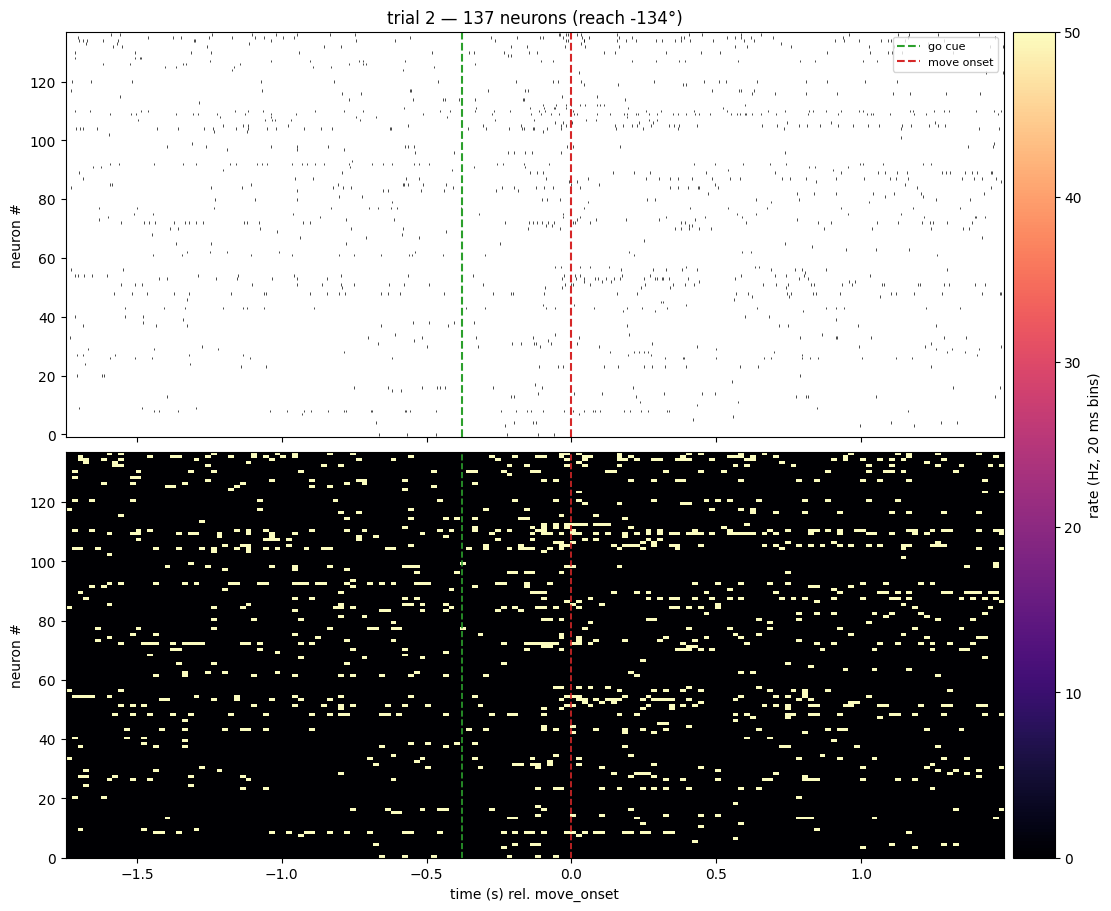

In [ ]:
# --- 5a. Spike raster + per-neuron firing-rate heatmap, one trial ---
def trial_window(ds, row):
    """Rows of ds.data within one trial's [start_time, end_time].

    Use a boolean mask, not .loc[start:end]: the native 1 ms index doesn't
    label-slice reliably under pandas >= 1.5 (it silently returns everything).
    """
    idx = ds.data.index
    return ds.data[(idx >= row["start_time"]) & (idx <= row["end_time"])]


def binned_rates(counts, dt_ms, win_ms):
    """Per-neuron firing rate (Hz) in simple, non-overlapping windows.

    counts: (T, N) spike counts at `dt_ms` resolution. Bins T into consecutive
    windows of `win_ms` (no overlap, no smoothing), sums within each window *per
    neuron*, then normalises to spikes/s. Returns (rate_hz (n_win, N), rows_per_window).

    Single-trial caveat: rates are quantised to multiples of 1000/win_ms Hz (one
    spike/window). Small windows (20 ms) -> 0/50/100 Hz (basically the raster);
    wider windows (50-100 ms) collect more spikes and look graded.
    """
    T, N = counts.shape
    w = max(1, int(round(win_ms / dt_ms)))               # source rows per window
    nb = T // w                                          # whole windows only
    per_win = counts[:nb * w].reshape(nb, w, N).sum(axis=1)   # spikes/window/neuron
    rate_hz = per_win / (w * dt_ms / 1000.0)             # -> per-neuron Hz
    return rate_hz, w


def plot_trial_raster(ds, trial_id, neurons=None, align="move_onset_time",
                      rate_win_ms=50):
    """One trial: spike raster (top) + per-neuron firing-rate heatmap (bottom),
    sharing the time axis. Each heatmap row is one neuron's rate over simple,
    non-overlapping `rate_win_ms` windows (same neuron ordering as the raster).

    `neurons`: None = all 137 held-in neurons, or an int for the first N.
    """
    row = ds.trial_info[ds.trial_info["trial_id"] == trial_id].iloc[0]
    spk = trial_window(ds, row)["spikes"]                # (T x 137), dt = ds.bin_width ms
    t = (spk.index - row[align]).total_seconds().to_numpy()

    cols = spk.columns if neurons is None else spk.columns[:neurons]
    counts = np.nan_to_num(spk[cols].to_numpy())
    N = counts.shape[1]

    rate_hz, w = binned_rates(counts, ds.bin_width, rate_win_ms)   # (n_win, N)
    used = len(rate_hz) * w
    centers = t[:used].reshape(-1, w).mean(axis=1)                 # window centres (s)
    dt = w * ds.bin_width / 1000.0                                 # window width (s)

    fig, (ax_r, ax_h) = plt.subplots(
        2, 1, figsize=(11, 9), sharex=True,
        gridspec_kw=dict(height_ratios=[1, 1]), constrained_layout=True)

    # top: spike raster
    ax_r.eventplot([t[counts[:, i] > 0] for i in range(N)], colors="black",
                   lineoffsets=np.arange(N), linelengths=0.9, linewidths=0.5)
    tx, ty = np.asarray(row["target_pos"], dtype=float)[row["active_target"]]
    ax_r.set(ylabel="neuron #", ylim=(-1, N),
             title=f"trial {trial_id} — {N} neurons "
                   f"(reach {np.degrees(np.arctan2(ty, tx)):.0f}\u00b0)")

    # bottom: per-neuron rate heatmap (neuron x time), same ordering as raster
    im = ax_h.imshow(rate_hz.T, aspect="auto", origin="lower", cmap="magma",
                     interpolation="nearest",
                     extent=[centers[0] - dt / 2, centers[-1] + dt / 2, 0, N],
                     vmax=np.percentile(rate_hz, 99) or None)      # clip a few hot bins
    ax_h.set(xlabel=f"time (s) rel. {align.replace('_time', '')}", ylabel="neuron #")
    fig.colorbar(im, ax=[ax_r, ax_h], label=f"rate (Hz, {rate_win_ms} ms bins)", pad=0.01)

    # event markers on both panels
    for field, color, label in [("go_cue_time", "tab:green", "go cue"),
                                 ("move_onset_time", "tab:red", "move onset")]:
        if pd.notnull(row[field]):
            x = (row[field] - row[align]).total_seconds()
            ax_r.axvline(x, color=color, ls="--", lw=1.5, label=label)
            ax_h.axvline(x, color=color, ls="--", lw=1.2)
    ax_r.legend(loc="upper right", fontsize=8)
    return fig


plot_trial_raster(ds_fine, EX_TRIAL)
plt.show()

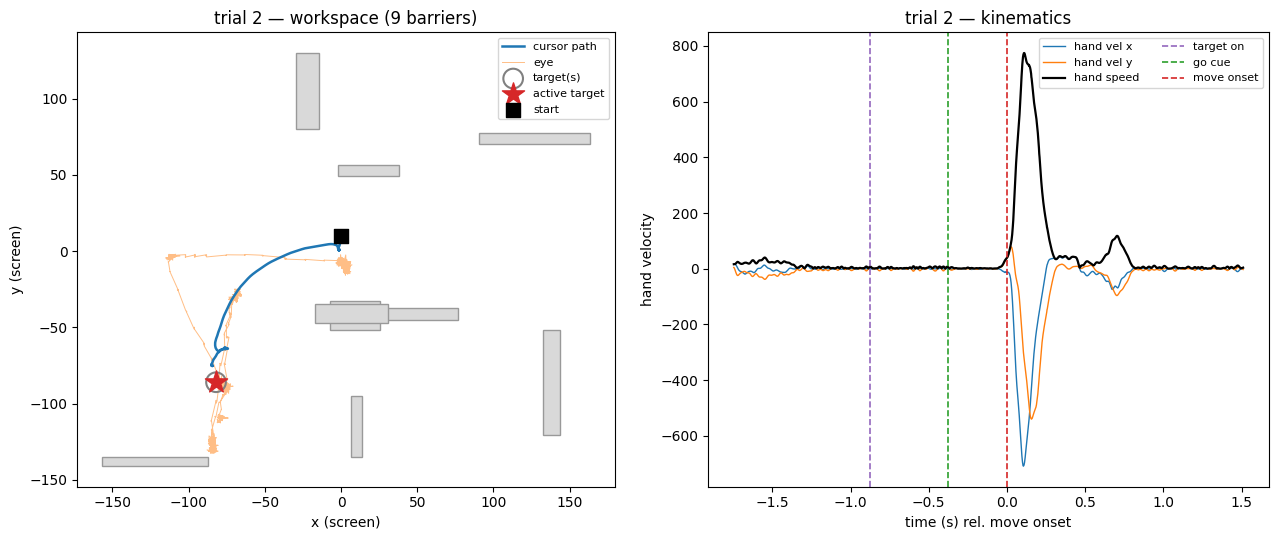

In [18]:
# --- 5b. Workspace geometry + kinematics, one trial ---
from matplotlib.patches import Rectangle


def plot_trial_geometry(ds, trial_id, barrier_is_center=True):
    """Left: workspace (targets, barriers, cursor + eye paths). Right: hand
    kinematics over time with event markers.

    `cursor_pos` shares the target coordinate frame, so it's the on-screen path;
    `hand_pos` is the physical manipulandum (y-shifted) and is shown only on the
    time axis. `barrier_pos` rows are [x, y, w, h]; `barrier_is_center` toggles
    whether (x, y) is the rectangle centre (assumed) or its lower-left corner.
    """
    row = ds.trial_info[ds.trial_info["trial_id"] == trial_id].iloc[0]
    t0 = row["move_onset_time"]
    seg = trial_window(ds, row)
    t = (seg.index - t0).total_seconds().to_numpy()

    targets = np.asarray(row["target_pos"], dtype=float)
    active = row["active_target"]
    barriers = np.asarray(row["barrier_pos"], dtype=float)
    barriers = barriers.reshape(-1, 4) if barriers.size else np.empty((0, 4))

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.5))

    # workspace
    for bx, by, bw, bh in barriers:
        ll = (bx - bw / 2, by - bh / 2) if barrier_is_center else (bx, by)
        axL.add_patch(Rectangle(ll, bw, bh, facecolor="0.85", edgecolor="0.6", zorder=1))
    cur = seg["cursor_pos"].dropna()
    axL.plot(cur["x"], cur["y"], color="tab:blue", lw=1.8, label="cursor path", zorder=4)
    eye = seg["eye_pos"].dropna()
    axL.plot(eye["x"], eye["y"], color="tab:orange", lw=0.7, alpha=0.5, label="eye", zorder=2)
    axL.scatter(targets[:, 0], targets[:, 1], s=200, facecolors="none",
                edgecolors="gray", linewidths=1.5, label="target(s)", zorder=5)
    axL.scatter(*targets[active], s=280, color="tab:red", marker="*",
                label="active target", zorder=6)
    axL.scatter(cur["x"].iloc[0], cur["y"].iloc[0], s=90, color="black",
                marker="s", label="start", zorder=6)
    axL.set(aspect="equal", xlabel="x (screen)", ylabel="y (screen)",
            title=f"trial {trial_id} — workspace ({row['num_barriers']} barriers)")
    axL.legend(fontsize=8, loc="best")

    # kinematics over time
    axR.plot(t, seg["hand_vel"]["x"], lw=1, label="hand vel x")
    axR.plot(t, seg["hand_vel"]["y"], lw=1, label="hand vel y")
    axR.plot(t, np.hypot(seg["hand_vel"]["x"], seg["hand_vel"]["y"]),
             color="black", lw=1.6, label="hand speed")
    for field, color, label in [("target_on_time", "tab:purple", "target on"),
                                 ("go_cue_time", "tab:green", "go cue"),
                                 ("move_onset_time", "tab:red", "move onset")]:
        if pd.notnull(row[field]):
            axR.axvline((row[field] - t0).total_seconds(), color=color, ls="--",
                        lw=1.2, label=label)
    axR.set(xlabel="time (s) rel. move onset", ylabel="hand velocity",
            title=f"trial {trial_id} — kinematics")
    axR.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    return fig


plot_trial_geometry(ds_fine, EX_TRIAL)
plt.show()